# Tutorial 8: Topological Data Analysis (Mapper)

**Duration:** 25-30 minutes

This tutorial covers the Mapper algorithm, a topological data analysis (TDA) technique for discovering the shape of data and identifying cell communities in tissue.

## Learning Objectives

By the end of this tutorial, you will be able to:
- Understand the Mapper algorithm conceptually
- Choose appropriate filter functions for spatial data
- Run Mapper analysis on tissue samples
- Interpret the resulting graph structure
- Identify hubs and communities in the Mapper graph

## Prerequisites

- Tutorials 1-7 completed
- Basic understanding of clustering concepts

## Biological Context

**What is Mapper?**

Mapper creates a simplified graph representation of high-dimensional data by:
1. Projecting data through a filter function
2. Covering the filter range with overlapping intervals
3. Clustering points within each interval
4. Connecting clusters that share points

**Applications in tissue biology:**
- Discovering cell communities without predefined labels
- Finding tissue gradients and transition zones
- Identifying hub cells connecting different regions
- Hypothesis generation for spatial organization

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spatialtissuepy import SpatialTissueData
from spatialtissuepy.topology import (
    # Main classes
    SpatialMapper,
    MapperResult,
    spatial_mapper,
    # Filters
    density_filter,
    eccentricity_filter,
    entropy_filter,
    # Spatial filters
    distance_to_type_filter,
    radial_filter,
    spatial_density_filter,
    composite_filter,
    # Analysis
    node_summary_dataframe,
    find_hub_nodes,
    find_bridge_nodes,
    component_statistics,
    extract_mapper_features,
)
from spatialtissuepy.viz import (
    plot_spatial_scatter,
    plot_mapper_graph,
    plot_mapper_spatial,
    plot_filter_distribution,
    plot_node_composition,
)

np.random.seed(42)

### Create sample tissue

In [2]:
# Create tissue with spatial structure
# Central tumor cluster
tumor = np.random.normal(loc=[500, 500], scale=80, size=(200, 2))
tumor_types = ['Tumor'] * 200

# Immune cells infiltrating from one side
immune = np.random.normal(loc=[300, 500], scale=100, size=(100, 2))
immune_types = ['CD8_T_cell'] * 100

# Stromal cells on the other side
stromal = np.random.normal(loc=[700, 500], scale=80, size=(80, 2))
stromal_types = ['Stromal'] * 80

# Scattered macrophages
macro = np.random.uniform(100, 900, size=(60, 2))
macro_types = ['Macrophage'] * 60

coordinates = np.vstack([tumor, immune, stromal, macro])
cell_types = np.array(tumor_types + immune_types + stromal_types + macro_types)

tissue = SpatialTissueData(coordinates=coordinates, cell_types=cell_types)
print(tissue)

SpatialTissueData
  Cells: 440
  Dimensions: 2D
  Cell types: 4
  Bounds: x=[52.8, 905.9], y=[114.3, 890.1]


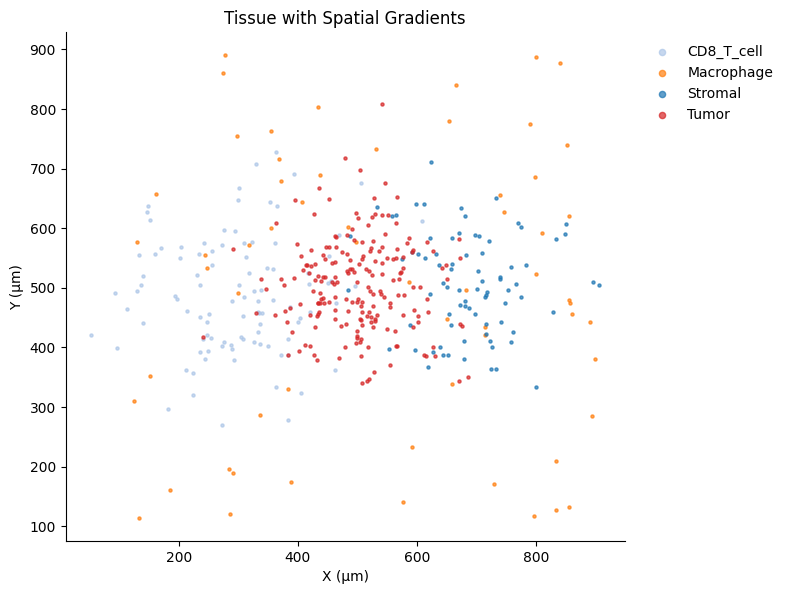

In [3]:
fig, ax = plt.subplots(figsize=(8, 8))
plot_spatial_scatter(tissue, ax=ax)
ax.set_title('Tissue with Spatial Gradients')
plt.tight_layout()
plt.show()

## Section 1: Understanding Filter Functions

The filter function projects cells onto a 1D or 2D space. Different filters reveal different aspects of the data.

### Built-in Filters:

| Filter | Description | Use Case |
|--------|-------------|----------|
| `density` | Local cell density | Find dense vs sparse regions |
| `eccentricity` | Distance from centroid | Find central vs peripheral cells |
| `entropy` | Neighborhood diversity | Find homogeneous vs heterogeneous regions |
| `distance_to_type` | Distance to specific cell type | Find gradients from cell populations |
| `radial` | Distance from reference point | Radial organization |
| `x_coordinate` | Spatial x-position | Horizontal gradients |

In [23]:
dt_filter?

Signature:
dt_filter(
    coordinates: 'np.ndarray',
    neighborhoods: 'np.ndarray',
    data: "'SpatialTissueData'",
) -> 'np.ndarray'
Docstring: <no docstring>
File:      ~/miniforge3/envs/spatialtissue-tutorials/lib/python3.10/site-packages/spatialtissuepy/topology/spatial_filters.py
Type:      function

AttributeError: 'NoneType' object has no attribute 'mean'

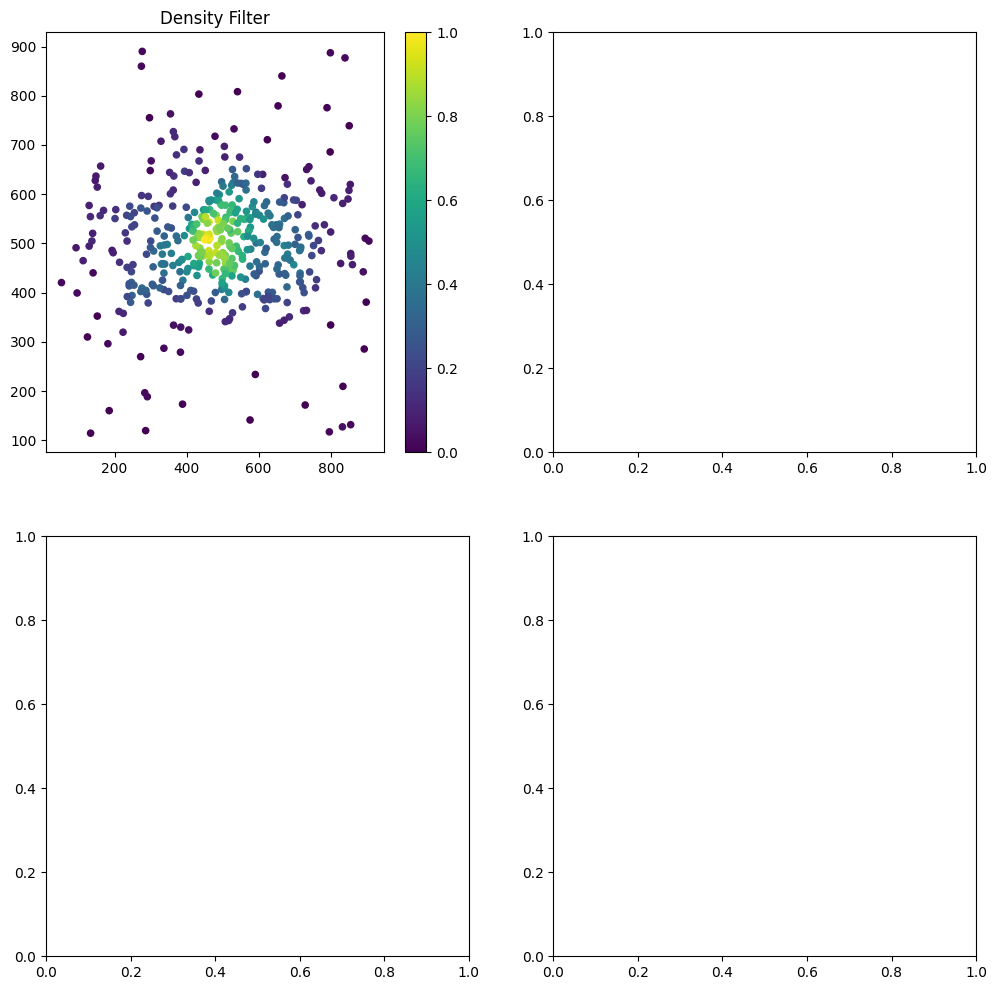

In [25]:
# Visualize different filter functions
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Density filter
density_filter = spatial_density_filter(radius=50.0)
density_vals = density_filter(
    coordinates=tissue.coordinates,
    neighborhoods=tissue._neighborhoods,
    data=tissue
)
scatter = axes[0, 0].scatter(tissue.coordinates[:, 0], tissue.coordinates[:, 1],
                              c=density_vals, cmap='viridis', s=20)
plt.colorbar(scatter, ax=axes[0, 0])
axes[0, 0].set_title('Density Filter')

# Eccentricity filter
ecc_filter = eccentricity_filter()
eccentric_vals = ecc_filter(
    coordinates=tissue.coordinates,
    neighborhoods=tissue._neighborhoods,
    data=tissue
)
scatter = axes[0, 1].scatter(tissue.coordinates[:, 0], tissue.coordinates[:, 1],
                              c=eccentric_vals, cmap='viridis', s=20)
plt.colorbar(scatter, ax=axes[0, 1])
axes[0, 1].set_title('Eccentricity Filter (distance from center)')

# Distance to Tumor
dt_filter = distance_to_type_filter('Tumor')
dist_to_tumor = dt_filter(
    coordinates=tissue.coordinates,
    neighborhoods=tissue._neighborhoods,
    data=tissue
)
scatter = axes[1, 0].scatter(tissue.coordinates[:, 0], tissue.coordinates[:, 1],
                              c=dist_to_tumor, cmap='viridis', s=20)
plt.colorbar(scatter, ax=axes[1, 0])
axes[1, 0].set_title('Distance to Tumor')

# X-coordinate (spatial gradient)
x_vals = tissue.coordinates[:, 0]
scatter = axes[1, 1].scatter(tissue.coordinates[:, 0], tissue.coordinates[:, 1],
                              c=x_vals, cmap='viridis', s=20)
plt.colorbar(scatter, ax=axes[1, 1])
axes[1, 1].set_title('X-Coordinate Filter')

plt.tight_layout()
plt.show()

## Section 2: Running Mapper

### 2.1 Quick Mapper with Convenience Function

In [ ]:
# Run Mapper with density filter
result = spatial_mapper(
    tissue,
    filter_fn='density',
    n_intervals=10,
    overlap=0.5,
    neighborhood_radius=50.0
)

print("Mapper Result:")
print(f"  Nodes: {result.n_nodes}")
print(f"  Edges: {result.n_edges}")
print(f"  Connected components: {result.n_components}")

In [ ]:
# Visualize the Mapper graph
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Mapper graph
plot_mapper_graph(result, ax=axes[0], color_by='size')
axes[0].set_title('Mapper Graph (node size = cell count)')

# Spatial embedding
plot_mapper_spatial(result, tissue, ax=axes[1])
axes[1].set_title('Mapper Nodes on Tissue')

plt.tight_layout()
plt.show()

### 2.2 Using the Class Interface

In [ ]:
# More control with SpatialMapper class
mapper = SpatialMapper(
    filter_fn=distance_to_type_filter('Tumor'),
    n_intervals=12,
    overlap=0.4,
    clusterer='dbscan',  # or 'agglomerative', 'kmeans'
    clusterer_params={'eps': 30, 'min_samples': 3}
)

result_tumor = mapper.fit(tissue, neighborhood_radius=50.0)

print(f"Mapper with distance-to-tumor filter:")
print(f"  Nodes: {result_tumor.n_nodes}")
print(f"  Edges: {result_tumor.n_edges}")

## Section 3: Analyzing Mapper Results

### 3.1 Node Summary

In [ ]:
# Get summary of all nodes
node_df = node_summary_dataframe(result, tissue)

print("Node Summary (first 10):")
print(node_df.head(10))

In [ ]:
# Analyze node cell type compositions
print("\nNode Compositions:")
for node_id in range(min(5, result.n_nodes)):
    node = result.nodes[node_id]
    cell_indices = node.members
    types_in_node = tissue.cell_types[cell_indices]
    unique, counts = np.unique(types_in_node, return_counts=True)
    
    print(f"\nNode {node_id} ({len(cell_indices)} cells):")
    for ct, c in zip(unique, counts):
        print(f"  {ct}: {c} ({100*c/len(cell_indices):.0f}%)")

### 3.2 Finding Hubs and Bridges

In [ ]:
# Find hub nodes (highly connected)
hubs = find_hub_nodes(result, top_n=5)

print("Top 5 Hub Nodes (most edges):")
for node_id, degree in hubs:
    n_cells = len(result.nodes[node_id].members)
    print(f"  Node {node_id}: {degree} edges, {n_cells} cells")

In [ ]:
# Find bridge nodes (connect different regions)
bridges = find_bridge_nodes(result)

if bridges:
    print(f"\nBridge Nodes (connect otherwise separate regions): {bridges}")
else:
    print("\nNo bridge nodes found (graph may be well-connected)")

### 3.3 Component Analysis

In [ ]:
# Analyze connected components
comp_stats = component_statistics(result, tissue)

print("Connected Component Statistics:")
for comp_id, stats in comp_stats.items():
    print(f"\nComponent {comp_id}:")
    print(f"  Nodes: {stats['n_nodes']}")
    print(f"  Total cells: {stats['n_cells']}")
    print(f"  Dominant type: {stats['dominant_type']}")

## Section 4: Different Filter Functions

### 4.1 Comparing Filter Choices

In [ ]:
# Run Mapper with different filters
filters = [
    ('density', 'density'),
    ('eccentricity', eccentricity_filter),
    ('x_coordinate', lambda data: data.coordinates[:, 0]),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, (name, filter_fn) in zip(axes, filters):
    result = spatial_mapper(
        tissue,
        filter_fn=filter_fn,
        n_intervals=10,
        overlap=0.5,
        neighborhood_radius=50.0
    )
    plot_mapper_graph(result, ax=ax, color_by='size')
    ax.set_title(f'{name}\n({result.n_nodes} nodes, {result.n_edges} edges)')

plt.tight_layout()
plt.show()

### 4.2 Composite Filters

In [ ]:
# Create composite filter (combination of multiple filters)
def my_composite_filter(data):
    density = spatial_density_filter(data, radius=50.0)
    x_coord = data.coordinates[:, 0]
    
    # Normalize both
    density_norm = (density - density.min()) / (density.max() - density.min())
    x_norm = (x_coord - x_coord.min()) / (x_coord.max() - x_coord.min())
    
    # Combine with weights
    return 0.5 * density_norm + 0.5 * x_norm

result_composite = spatial_mapper(
    tissue,
    filter_fn=my_composite_filter,
    n_intervals=10,
    overlap=0.5
)

print(f"Composite filter result: {result_composite.n_nodes} nodes, {result_composite.n_edges} edges")

## Section 5: Feature Extraction

In [ ]:
# Extract features from Mapper result
features = extract_mapper_features(result)

print("Mapper Features:")
for key, value in features.items():
    if isinstance(value, float):
        print(f"  {key}: {value:.4f}")
    else:
        print(f"  {key}: {value}")

## Section 6: Parameter Sensitivity

### Key Parameters:
- **n_intervals:** Number of bins in the filter (more = finer resolution)
- **overlap:** Fraction of overlap between bins (higher = more connectivity)

In [ ]:
# Effect of n_intervals
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, n_int in zip(axes, [5, 10, 15, 20]):
    result = spatial_mapper(tissue, filter_fn='density', n_intervals=n_int, overlap=0.5)
    plot_mapper_graph(result, ax=ax, color_by='size')
    ax.set_title(f'n_intervals={n_int}\n({result.n_nodes} nodes)')

plt.tight_layout()
plt.show()

In [ ]:
# Effect of overlap
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, overlap in zip(axes, [0.2, 0.4, 0.6, 0.8]):
    result = spatial_mapper(tissue, filter_fn='density', n_intervals=10, overlap=overlap)
    plot_mapper_graph(result, ax=ax, color_by='size')
    ax.set_title(f'overlap={overlap}\n({result.n_edges} edges)')

plt.tight_layout()
plt.show()

print("\nLower overlap = fewer edges (more disconnected)")
print("Higher overlap = more edges (more connected)")

## Exercise: Discover Tissue Communities

1. **Filter selection:** Try `distance_to_type_filter('CD8_T_cell')` to find gradients from immune cells. How does the Mapper graph change?

2. **Community labeling:** For each connected component in your best Mapper result, determine the dominant cell type and give it a biological label.

3. **Hub cell analysis:** Extract the actual cells in hub nodes. What are their cell types? Where are they located?

In [ ]:
# Your code here


## Summary

In this tutorial, you learned:

- **Mapper algorithm:** How it creates graph representations of data shape
- **Filter functions:** Different projections reveal different aspects of tissue organization
- **Result interpretation:** Nodes represent cell communities, edges represent overlap
- **Hub/bridge analysis:** Identifying structurally important cells
- **Parameter tuning:** Effects of n_intervals and overlap

**Key insights:**
- Mapper provides hypothesis-free discovery of tissue structure
- Filter choice determines what aspects of organization are revealed
- Hubs and bridges identify transition zones between regions
- Features extracted from Mapper can be used for sample comparison

## Next Steps

- **Tutorial 9: Visualization** - Publication-quality plotting
- **Tutorial 10: Multi-Sample** - Comparing samples using Mapper features